#comando do terminal pycharm

In [ ]:
# 📂 Navegação e Arquivos
# Comando	O que faz
# ls	Lista os arquivos da pasta atual
# ls -R	Lista todos os arquivos, incluindo subpastas
# cd nome_da_pasta	Entra em uma pasta
# cd ..	Volta para a pasta anterior
# pwd	Mostra o caminho completo de onde você está agora
# 🐍 Ambiente Virtual (venv)
# Comando	O que faz
# python3 -m venv venv	Cria o ambiente virtual chamado "venv"
# source venv/bin/activate	Ativa o ambiente (essencial para rodar o código)
# deactivate	Desativa o ambiente virtual
# 📦 Gerenciamento de Bibliotecas (pip)
# Comando	O que faz
# pip install pandas	Instala a biblioteca Pandas
# pip uninstall nome	Remove uma biblioteca instalada
# pip list	Mostra todas as bibliotecas instaladas no seu venv
# pip freeze > requirements.txt	Salva a lista de bibliotecas do projeto num arquivo
# pip install -r requirements.txt	Instala tudo o que está listado no arquivo de requisitos
# 🚀 Execução
# Comando	O que faz
# python src/evalute.py	Executa o script que está dentro da pasta src
# python --version	Verifica qual versão do Python está ativa no momento

# Comando do terminal pycharm

In [24]:
# source venv/bin/activate (Tentativa inicial de ativar o ambiente)
# ls -l (Listar arquivos com detalhes)
# ll (Comando não encontrado)
# ls (Listar arquivos)
# python3.8 -m venv venv (Criar o ambiente virtual)
# sorce venv\bin\activate (Erro de digitação em "source" e uso de barra invertida)
# source venv\bin\activate (Uso de barra invertida, que o macOS/Linux não reconhece para caminhos)
# source venv/bin/activate (Ativação correta do venv)
# python3.8 evalute.py (Tentativa de rodar o arquivo fora da pasta src)
# ls (Verificar pastas)
# ll (Comando não encontrado)
# ls -la (Listar todos os arquivos, incluindo ocultos)
# python3.8 src/evalute.py (Tentativa de rodar o script; deu erro de falta do pandas)
# pip install panda (Erro de digitação: instalou a biblioteca panda em vez de pandas)
# python3.8 src/evalute.py (Erro de pandas persistiu)
# pip install panda (Tentativa repetida)
# ls -R (Listagem recursiva de todas as pastas e arquivos do projeto)

#comando do terminal pycharm


In [ ]:
# para executar o diretorio src-1 train.py

# source venv/bin/activate
# python src/preprocesso.py
# python src-1/train.py

# uma dica de oura se quiser juntar dois diretorios separados para poder ver o resultado:
# python src-1/train.py && python src-2/evaluate.py

#da aula ia sobre explainer ia em portugues ia explicativa

In [ ]:
#Biblioteca
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [ ]:
#1 Carregar dataset do aluno universitario
df = pd.read_csv("dataset_alunos_universitarios.csv")


In [ ]:
# 1 linha do dataset do aluno universitario
print("\nPrimeiro linhas do dataset: ")
print(df.head())


Primeiro linhas do dataset: 
   idade     genero estado_civil tipo_escola_ensino_medio  nota_enem  \
0     22   Feminino     Solteiro                  Pública        698   
1     32  Masculino     Solteiro                  Pública        632   
2     28   Feminino     Solteiro                  Pública        663   
3     20   Feminino     Solteiro                  Privada        759   
4     19   Feminino     Solteiro                  Pública        661   

   renda_familiar bolsa_estudos mora_com_familia          trabalha  \
0            10.0           Sim              Sim      Meio período   
1             1.9           Não              Sim      Não trabalha   
2             0.5           Não              Não      Meio período   
3             8.3           Não              Sim  Período integral   
4             8.5           Não              Não      Meio período   

   horas_estudo_semanal tem_computador  distancia_campus_km  \
0                    13            Sim               

In [ ]:
#Esse é a informação do dataset do aluno universitario
print("\nInformação do dataset: ")
print(df.info())


Informação do dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   idade                          1000 non-null   int64  
 1   genero                         1000 non-null   object 
 2   estado_civil                   1000 non-null   object 
 3   tipo_escola_ensino_medio       1000 non-null   object 
 4   nota_enem                      1000 non-null   int64  
 5   renda_familiar                 1000 non-null   float64
 6   bolsa_estudos                  1000 non-null   object 
 7   mora_com_familia               1000 non-null   object 
 8   trabalha                       1000 non-null   object 
 9   horas_estudo_semanal           1000 non-null   int64  
 10  tem_computador                 1000 non-null   object 
 11  distancia_campus_km            1000 non-null   float64
 12  recebe_assistencia_estud

In [ ]:
# 2 Pré processamento
#Converter variáveis categóricas para numéricas
le_dict = {}

for col in df.select_dtypes(include='object').columns:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  le_dict[col] = le


In [ ]:
#Separar features e target
X = df.drop("status_curso", axis=1)
y = df["status_curso"]

print("\nFeatures: ")
print(X.columns)


Features: 
Index(['idade', 'genero', 'estado_civil', 'tipo_escola_ensino_medio',
       'nota_enem', 'renda_familiar', 'bolsa_estudos', 'mora_com_familia',
       'trabalha', 'horas_estudo_semanal', 'tem_computador',
       'distancia_campus_km', 'recebe_assistencia_estudantil',
       'primeira_opcao_curso'],
      dtype='object')


In [ ]:
#3 divisão treino / teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
# 5 avaliar modelo
y_pred = model.predict(X_test)

print("\nRelatório de classificação: ")
print(classification_report(y_test, y_pred))


Relatório de classificação: 
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       139
           1       0.98      0.95      0.97        61

    accuracy                           0.98       200
   macro avg       0.98      0.97      0.98       200
weighted avg       0.98      0.98      0.98       200



In [ ]:
#Feature importance

importances = model.feature_importances_

features_importances = pd.DataFrame({
    "feature" : X.columns,
    "importances" : importances
})

In [ ]:
features_importances = features_importances.sort_values(
    by="importances",
    ascending=False
)

In [ ]:
print(f"Feature importance")
print(features_importances)

Feature importance
                          feature  importances
11            distancia_campus_km     0.328405
5                  renda_familiar     0.238238
0                           idade     0.149024
4                       nota_enem     0.130505
10                 tem_computador     0.037940
9            horas_estudo_semanal     0.033615
8                        trabalha     0.033383
13           primeira_opcao_curso     0.018878
3        tipo_escola_ensino_medio     0.006206
1                          genero     0.005069
6                   bolsa_estudos     0.005067
2                    estado_civil     0.005048
12  recebe_assistencia_estudantil     0.004546
7                mora_com_familia     0.004077


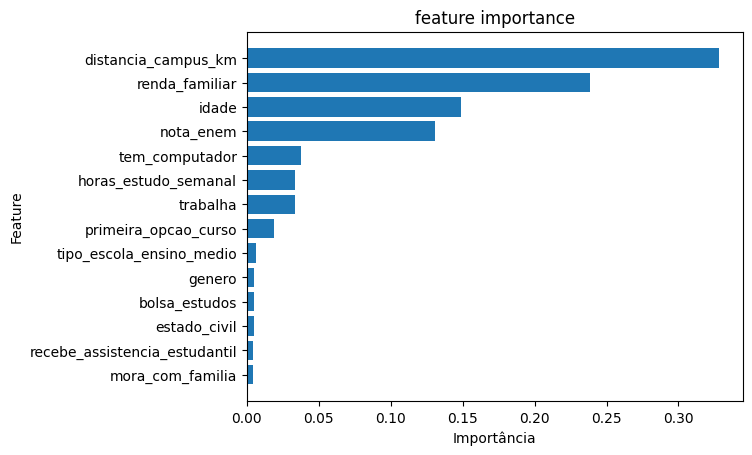

In [ ]:
plt.figure()
plt.barh(features_importances["feature"], features_importances["importances"])
plt.gca().invert_yaxis()
plt.title("feature importance")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

In [ ]:
#Sha
#Criar o explainer
explainer = shap.TreeExplainer(model, X_train)

#Calcular os valores do SHAP
shap_values = explainer.shap_values(X_test)

#Selecionar uma classes (evadiu ou concluiu)
shap_class = shap_values[:,:,1]

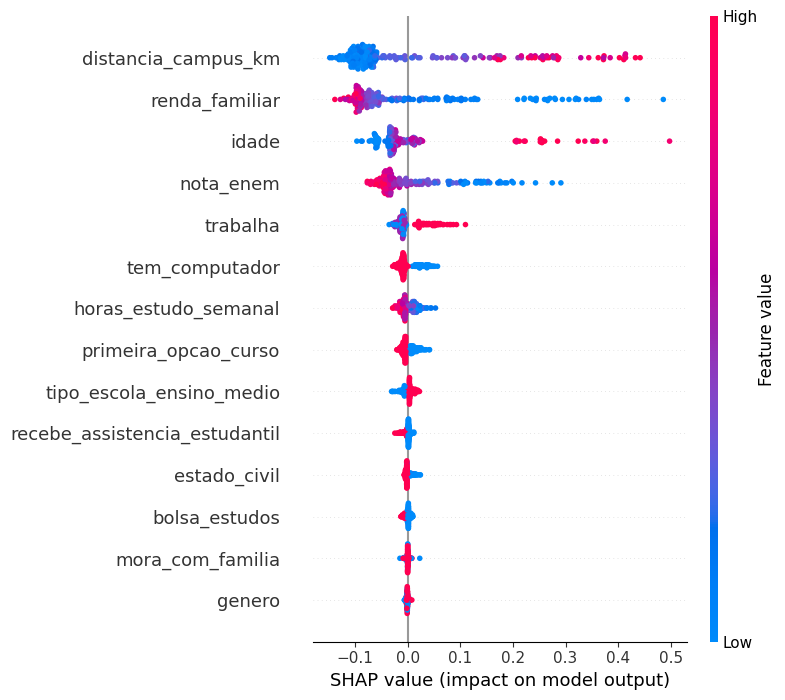

In [ ]:
#Gerar gráfico beeswarm (enxame de abelhas)
shap.summary_plot(
    shap_class,
    X_test,
    feature_names = X_test.columns
)

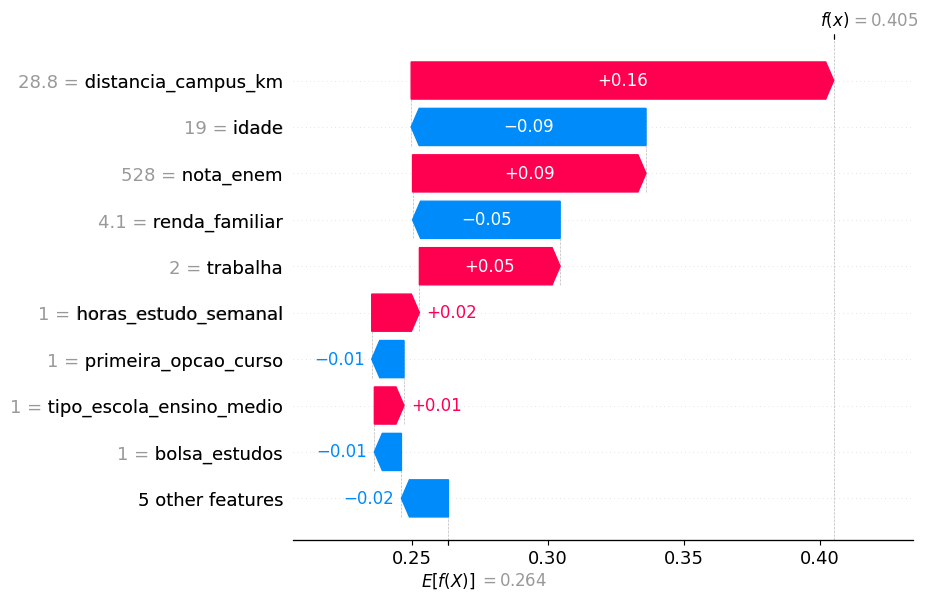

In [ ]:
# Explicação de uma previsão individual

index = 10
shap.plots.waterfall(
    shap.Explanation(
        values=shap_class[index],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[index],
        feature_names=X_test.columns
    )
)

In [ ]:
# Exemplo de previsão com explicação

index = 10
sample = X_test.iloc[[index]]
prediction = model.predict(sample)[0]
prob = model.predict_proba(sample)[0]

print(f"Previsão: {prediction}")
print(f"Probabilidade: {prob}")

print(f"Valores da amostra: {sample}")

Previsão: 0
Probabilidade: [0.595 0.405]
Valores da amostra:      idade  genero  estado_civil  tipo_escola_ensino_medio  nota_enem  \
811     19       0             2                         1        528   

     renda_familiar  bolsa_estudos  mora_com_familia  trabalha  \
811             4.1              1                 1         2   

     horas_estudo_semanal  tem_computador  distancia_campus_km  \
811                     1               1                 28.8   

     recebe_assistencia_estudantil  primeira_opcao_curso  
811                              0                     1  
